## Figure A5 - Tahoe LFC KNN Boxplot (No-Tahoe LPM Embeddings)

All models are evaluated on the compound subset covered by `no_tahoe_embeddings/tahoe_sci_op3_no_tahoe_embeddings.pkl`.
Scores are loaded from `results/scores/no_tahoe_embeddings/tahoe_lfc_restricted.csv`.


In [1]:
import pandas as pd
import seaborn as sns
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl


In [2]:
results_path = "/Users/matthewmella/repos/foundation-models-perturbation/results/"


In [3]:
df = pd.read_csv(results_path + "scores/no_tahoe_embeddings/tahoe_lfc_restricted.csv", index_col=0)
print(f"Loaded {len(df)} rows, {df['name'].nunique()} unique models")
df.head()


Loaded 12375 rows, 55 unique models


,dataset,fold,metrics,name,primary_metric,L2,MSE,MAE,Spearman,Pearson,cell_line
0,expression/pert_prediction_tahoe_regression,CVCL_0028.0,"{'primary_metric': 'L2', 'L2': 6.1356289037704...",knn_baseline_LPM_emb,L2,6.135629,0.002198,0.022139,0.244111,0.328740,CVCL_0028
1,expression/pert_prediction_tahoe_regression,CVCL_0069.0,"{'primary_metric': 'L2', 'L2': 5.2563740073870...",knn_baseline_LPM_emb,L2,5.256374,0.001704,0.017915,0.295786,0.402596,CVCL_0069
2,expression/pert_prediction_tahoe_regression,CVCL_0023.0,"{'primary_metric': 'L2', 'L2': 5.6927040964318...",knn_baseline_LPM_emb,L2,5.692704,0.001991,0.017513,0.307894,0.384163,CVCL_0023
3,expression/pert_prediction_tahoe_regression,CVCL_0099.0,"{'primary_metric': 'L2', 'L2': 5.3591782930533...",knn_baseline_LPM_emb,L2,5.359178,0.001787,0.017709,0.272038,0.385786,CVCL_0099
4,expression/pert_prediction_tahoe_regression,CVCL_0131.0,"{'primary_metric': 'L2', 'L2': 5.7632805053512...",knn_baseline_LPM_emb,L2,5.763281,0.002036,0.018771,0.317811,0.421647,CVCL_0131


In [4]:
# Load plotting metadata (palette, hue order, mpl params)
with open(results_path + "metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

model_type_palette = fig_index['drugs_model_type_palette']
model_type_palette["Response Embedding"] = "#8CD17DFF"
hue_order = [*fig_index['drugs_hue_order'], "Response Embedding"]
mpl.rcParams.update(fig_index["mpl_params"])


In [5]:
# Build method_map: internal name -> (display name, model type)
# Start with existing fig_index entries (KNN only)
lasso_or_knn = "knn"

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn): v
    for k, v in fig_index["tahoe_lfc"].items()
}

# Add new pkl embedding models
# method_map["knn_baseline_ECFP:2_pkl"] = ["ECFP:2 (LPM)", "Molecule Structure"]
method_map["knn_baseline_LPM_emb"] = ["LPM", "Response Embedding"]

print(f"Models in method_map: {len(method_map)}")
for k, v in method_map.items():
    print(f"  {k} -> {v[0]} ({v[1]})")


Models in method_map: 29
  context mean baseline -> Train Mean (Negative Control)
  no change baseline -> No Change (Negative Control)
  knn_baseline_random -> Random Embeddings (Negative Control)
  knn_baseline_ChemBERTa-77M-MLM -> ChemBERTa-77M-MLM (SMILES Transformer)
  knn_baseline_ChemBERTa-77M-MTR -> ChemBERTa-77M-MTR (SMILES Transformer)
  knn_baseline_MiniMol -> MiniMol (SMILES Transformer)
  knn_baseline_MolT5 -> MolT5 (SMILES Transformer)
  knn_baseline_boltz_affinity_pred_value_fragment -> Boltz (Fragment) (Protein Affinity)
  knn_baseline_boltz_affinity_pred_value_protein -> Boltz (Protein) (Protein Affinity)
  knn_baseline_boltz_affinity_probability_binary_fragment -> Boltz Binding Probability (Fragment) (Protein Affinity)
  knn_baseline_boltz_affinity_probability_binary_protein -> Boltz Binding Probability (Protein) (Protein Affinity)
  knn_baseline_chatgpt -> ChatGPT (LLM)
  knn_baseline_maccs -> MACCS (Molecule Structure)
  knn_baseline_topological -> Topological (Molec

Rows after filtering to known models: 6075
Best non-control model: MiniMol (median L2=5.9883, type=SMILES Transformer)


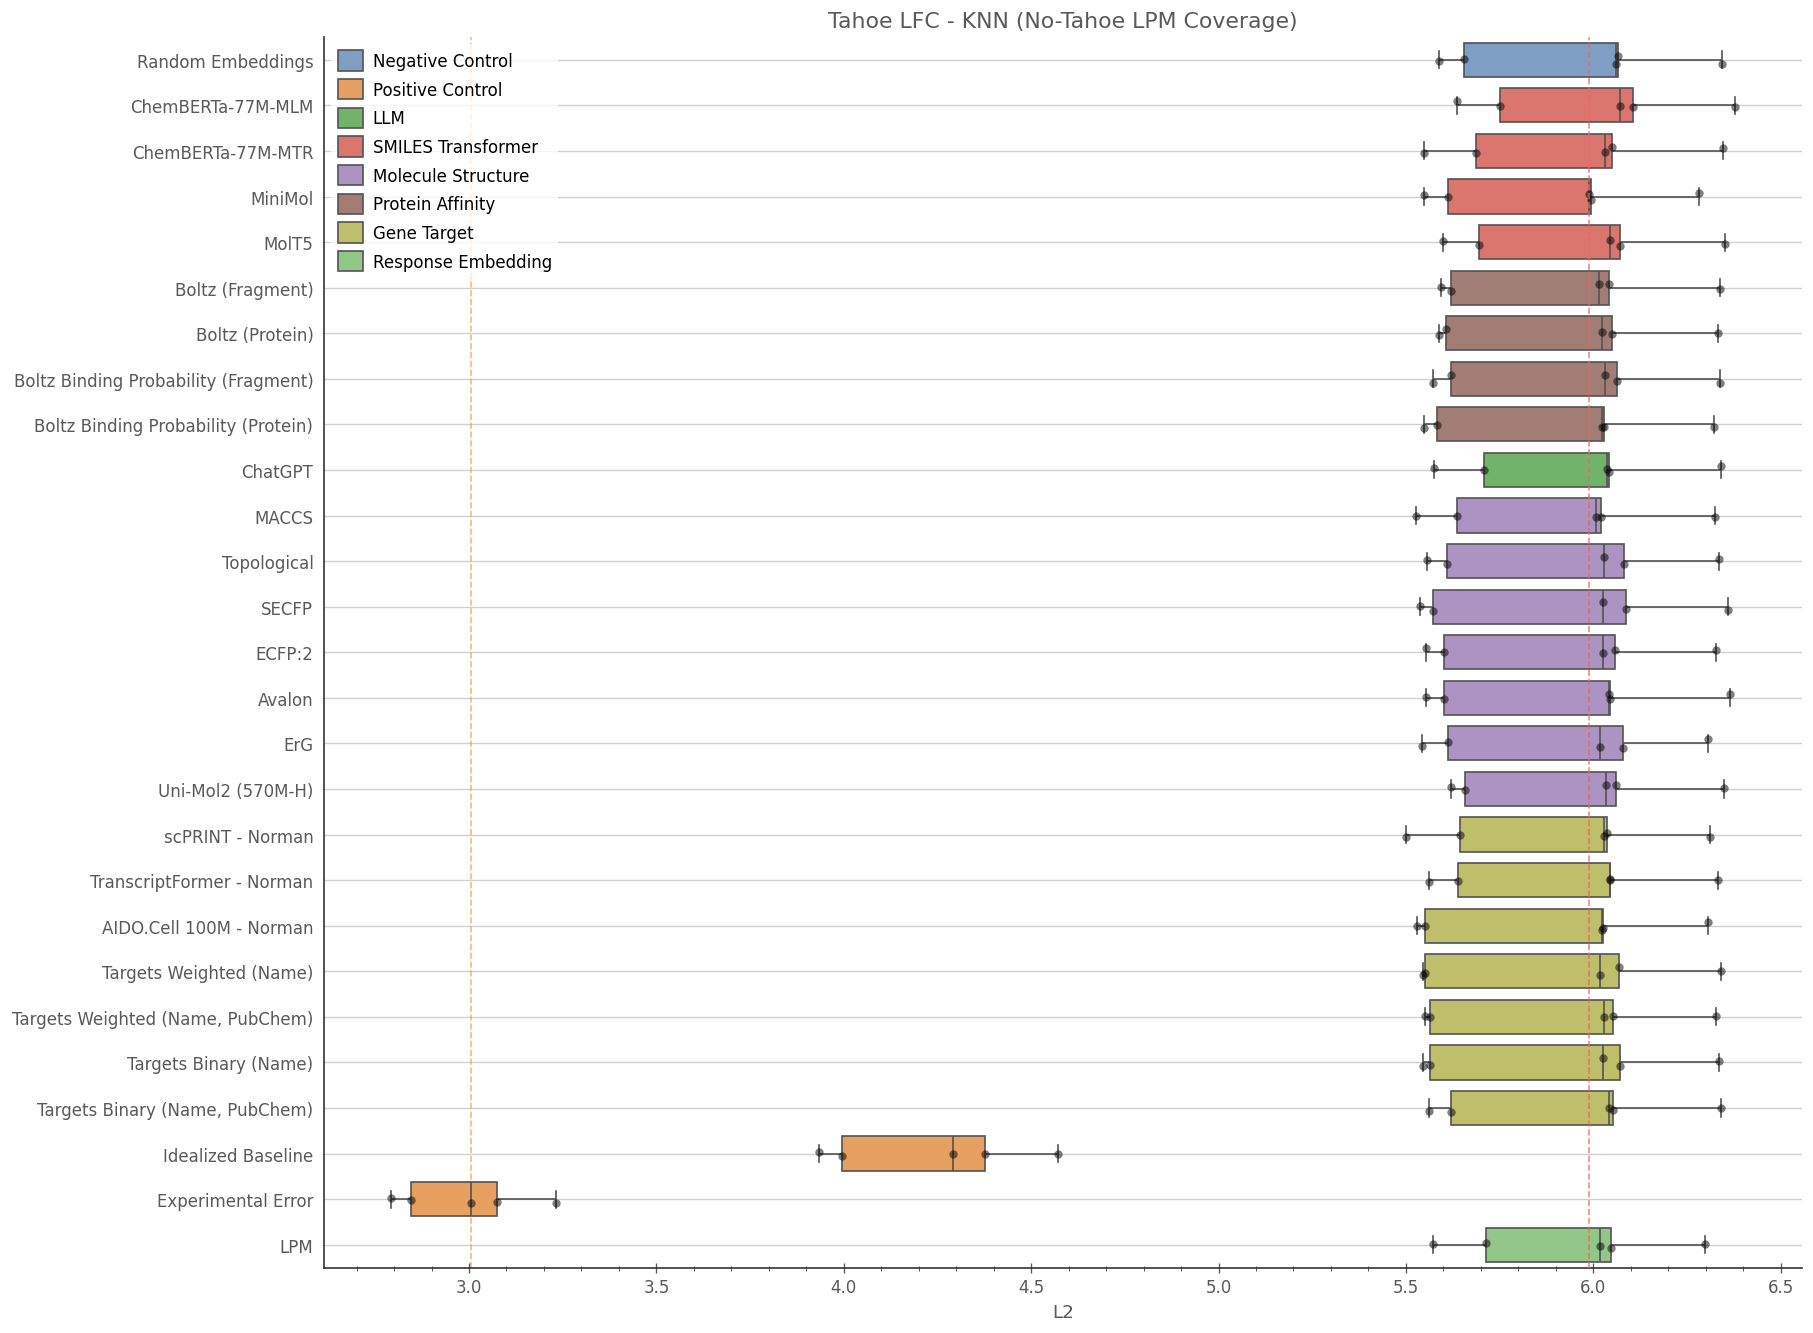

In [6]:
fig, ax = plt.subplots(figsize=(15, 11), constrained_layout=True)

df_subset = df[df["name"].isin(method_map)].copy()
print(f"Rows after filtering to known models: {len(df_subset)}")

df_subset["fold"] = df_subset["fold"].apply(
    lambda x: x if "." not in str(x) else x.split(".")[1]
)
df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

# Aggregate: mean L2 across cell lines, per fold
df_subset = df_subset.groupby(["fold", "name", "Model type"])["L2"].mean().reset_index()

present_hues = [
    h for h in hue_order
    if h in df_subset["Model type"].unique()
]

# Order: follow method_map order, only include names present in data
name_order = [name for name, _ in method_map.values() if name in df_subset["name"].values]

# Boxplot
g = sns.boxplot(
    data=df_subset,
    y="name",
    order=name_order,
    hue="Model type",
    hue_order=present_hues,
    x="L2",
    ax=ax,
    whis=(0, 100),
    width=0.75,
    palette=model_type_palette,
)

# Overlay stripplot
sns.stripplot(
    data=df_subset,
    y="name",
    order=name_order,
    color="black",
    alpha=0.5,
    s=5,
    x="L2",
    ax=ax,
)

# Decorate
g.grid(axis="y")
g.set(ylabel=None, title="Tahoe LFC - KNN (No-Tahoe LPM Coverage)")
g.set_xlabel('L2')
g.legend(title=None)

# Get the best performing model (excluding positive controls and fusion)
best_mask = (
    (df_subset["Model type"] != "Positive Control") &
    (df_subset["Model type"] != "Fusion")
)
best_group = (
    df_subset.loc[best_mask]
    .groupby("name")["L2"]
    .median()
)
best_name = best_group.idxmin()
best_level = best_group.loc[best_name]
best_model_type = (
    df_subset.loc[df_subset["name"] == best_name, "Model type"]
    .iloc[0]
)

# Draw vertical reference lines
# Train Mean line
train_mean_data = df_subset[df_subset["name"] == "Train Mean"]["L2"]
if len(train_mean_data) > 0:
    g.axvline(
        train_mean_data.median(),
        color=model_type_palette["Negative Control"],
        linestyle="--",
        linewidth=1,
        zorder=99,
        alpha=0.75,
    )

# Experimental Error line
exp_error_data = df_subset[df_subset["name"] == "Experimental Error"]["L2"]
if len(exp_error_data) > 0:
    g.axvline(
        exp_error_data.median(),
        color=model_type_palette["Positive Control"],
        linestyle="--",
        linewidth=1,
        zorder=-99,
        alpha=0.75,
    )

# Best model line
g.axvline(
    best_level,
    color=model_type_palette[best_model_type],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)

print(f"Best non-control model: {best_name} (median L2={best_level:.4f}, type={best_model_type})")

plt.savefig("fig_A5_no_tahoe_embeddings.pdf")
plt.savefig("fig_A5_no_tahoe_embeddings.png", dpi=200)
plt.show()
